# Data Cleaning of Loan Defaulter Project

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ldp = pd.read_csv("credit_risk_dataset.csv")

In [4]:
ldp

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1
...,...,...,...,...,...,...,...,...
995,53,44519.0,7307,433,22,PhD,Rent,1
996,22,107487.0,44901,582,7,High School,Own,1
997,34,102870.0,16205,372,29,Masters,Rent,0
998,60,66197.0,10906,780,24,PhD,Own,0


In [5]:
ldp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1000 non-null   int64  
 1   Income            985 non-null    float64
 2   Loan_Amount       1000 non-null   int64  
 3   Credit_Score      1000 non-null   int64  
 4   Employment_Years  1000 non-null   int64  
 5   Education_Level   1000 non-null   object 
 6   Housing_Status    1000 non-null   object 
 7   Default           1000 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 62.6+ KB


In [6]:
ldp.describe()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Default
count,1000.000000,985.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,42.515000,82254.047716,27729.324000,581.05000,15.164000,0.138000
std,12.611059,36842.390571,12774.836247,158.59334,8.593075,0.345073
min,21.000000,20922.000000,5097.000000,300.00000,0.000000,0.000000
25%,32.000000,52154.000000,16387.500000,441.00000,8.000000,0.000000
50%,43.000000,79379.000000,28483.500000,582.00000,15.000000,0.000000
75%,53.000000,116646.000000,38535.500000,720.25000,23.000000,0.000000
max,64.000000,149038.000000,49976.000000,849.00000,29.000000,1.000000


In [7]:
ldp.isnull().sum().sum()

np.int64(15)

In [8]:
ldp.isnull().sum()

Age                  0
Income              15
Loan_Amount          0
Credit_Score         0
Employment_Years     0
Education_Level      0
Housing_Status       0
Default              0
dtype: int64

In [9]:
ldp['Income'].isnull().sum()

np.int64(15)

In [10]:
ldp['Income'].mean()

np.float64(82254.04771573604)

In [11]:
ldp['Income'].skew()

np.float64(0.09447847377460729)

In [12]:
ldp['Income']=ldp['Income'].fillna(ldp['Income'].mean())

In [13]:
ldp['Income'].isnull().sum()

np.int64(0)

In [14]:
ldp.isnull().sum().sum()

np.int64(0)

# handled missing values completed

In [15]:
ldp.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1


# checked duplicate values

In [16]:
ldp.duplicated().sum()


np.int64(0)

# check unique values

In [17]:
for col in ldp.select_dtypes(include='object').columns:
    print(col)
    print(ldp[col].unique())
    print("-"*50)

Education_Level
['Bachelors' 'PhD' 'Masters' 'High School']
--------------------------------------------------
Housing_Status
['Own' 'Rent' 'Mortgage']
--------------------------------------------------


# checking outliers

In [18]:
l = ldp.select_dtypes(include=['int','float']).columns

In [19]:
l

Index(['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years',
       'Default'],
      dtype='object')

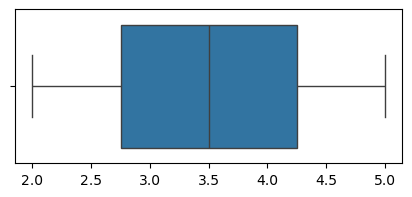

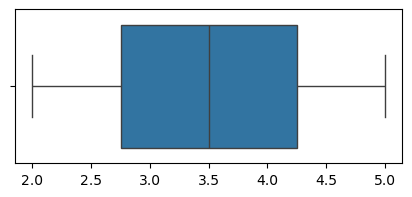

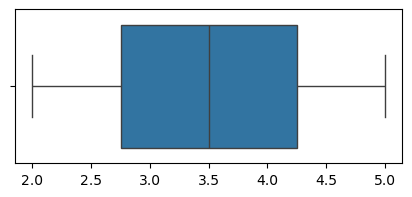

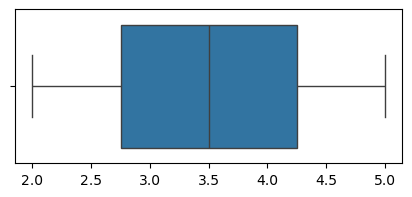

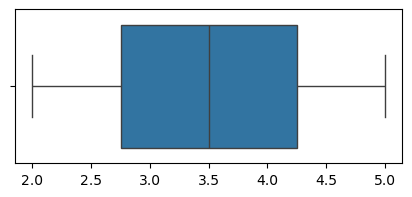

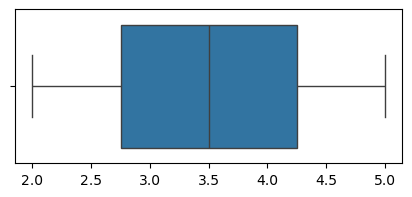

In [20]:
for col in l:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=(5,2))
    plt.show()

In [21]:
ldp.describe()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Default
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,42.515000,82254.047716,27729.324000,581.05000,15.164000,0.138000
std,12.611059,36564.749910,12774.836247,158.59334,8.593075,0.345073
min,21.000000,20922.000000,5097.000000,300.00000,0.000000,0.000000
25%,32.000000,52154.000000,16387.500000,441.00000,8.000000,0.000000
50%,43.000000,82254.047716,28483.500000,582.00000,15.000000,0.000000
75%,53.000000,116646.000000,38535.500000,720.25000,23.000000,0.000000
max,64.000000,149038.000000,49976.000000,849.00000,29.000000,1.000000


In [22]:
ldp.to_csv('loan_defaulter_cleaned.csv',index=False)